In [2]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [3]:
def reduce_mem_usage(df, use_category=True):
    start_mem = df.memory_usage(deep=True).sum() / 1024 ** 2
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if pd.api.types.is_integer_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast="integer")
        
        elif pd.api.types.is_float_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast="float")
        
        elif use_category and col_type == "object":
            num_unique = df[col].nunique(dropna=False)
            num_total = len(df[col])
            
            if num_unique / num_total < 0.5:
                df[col] = df[col].astype("category")
    
    end_mem = df.memory_usage(deep=True).sum() / 1024 ** 2
    reduction = 100 * (start_mem - end_mem) / start_mem
    
    print(f"Memory usage: {start_mem:.2f} MB -> {end_mem:.2f} MB")
    print(f"Reduced by {reduction:.2f}%")
    
    return df

In [4]:
train_transaction = pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv")
train_identity = pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv")
test_transaction = pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv")
test_identity = pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv")

train_transaction = reduce_mem_usage(train_transaction)
train_identity = reduce_mem_usage(train_identity)
test_transaction = reduce_mem_usage(test_transaction)
test_identity = reduce_mem_usage(test_identity)

Memory usage: 2062.07 MB -> 861.12 MB
Reduced by 58.24%
Memory usage: 143.14 MB -> 16.17 MB
Reduced by 88.70%
Memory usage: 1771.84 MB -> 738.37 MB
Reduced by 58.33%
Memory usage: 140.08 MB -> 15.95 MB
Reduced by 88.61%


In [5]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
train_transaction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 394 entries, TransactionID to V339
dtypes: category(14), float32(376), int16(1), int32(2), int8(1)
memory usage: 861.1 MB


In [7]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


In [8]:
train_identity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144233 entries, 0 to 144232
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   TransactionID  144233 non-null  int32   
 1   id_01          144233 non-null  float32 
 2   id_02          140872 non-null  float32 
 3   id_03          66324 non-null   float32 
 4   id_04          66324 non-null   float32 
 5   id_05          136865 non-null  float32 
 6   id_06          136865 non-null  float32 
 7   id_07          5155 non-null    float32 
 8   id_08          5155 non-null    float32 
 9   id_09          74926 non-null   float32 
 10  id_10          74926 non-null   float32 
 11  id_11          140978 non-null  float32 
 12  id_12          144233 non-null  category
 13  id_13          127320 non-null  float32 
 14  id_14          80044 non-null   float32 
 15  id_15          140985 non-null  category
 16  id_16          129340 non-null  category
 17  id_17     

In [9]:
train = train_transaction.merge(train_identity, on="TransactionID", how="left")
train = reduce_mem_usage(train)

Memory usage: 924.42 MB -> 924.42 MB
Reduced by 0.00%


In [10]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [13]:
target_counts = train["isFraud"].value_counts()
target_rate = train["isFraud"].mean()

print(target_counts)
print(f"Fraud rate: {target_rate:.4%}")

isFraud
0    569877
1     20663
Name: count, dtype: int64
Fraud rate: 3.4990%


In [16]:
train["TransactionAmt"].describe()

count    590540.000000
mean        135.027161
std         239.162689
min           0.251000
25%          43.320999
50%          68.769001
75%         125.000000
max       31937.390625
Name: TransactionAmt, dtype: float64

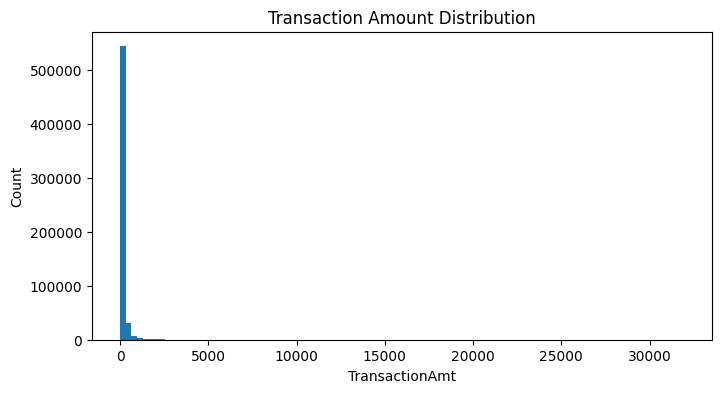

In [18]:
plt.figure(figsize=(8, 4))
plt.hist(train["TransactionAmt"], bins=100)
plt.title("Transaction Amount Distribution")
plt.xlabel("TransactionAmt")
plt.ylabel("Count")
plt.show()


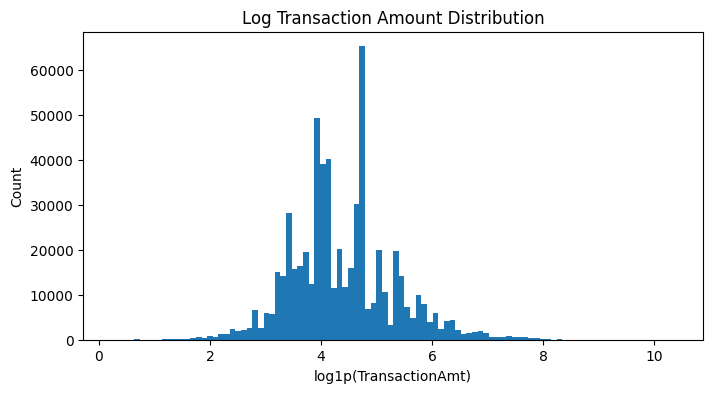

In [19]:
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(train["TransactionAmt"]), bins=100)
plt.title("Log Transaction Amount Distribution")
plt.xlabel("log1p(TransactionAmt)")
plt.ylabel("Count")
plt.show()

In [20]:
fraud_amt = train.loc[train["isFraud"] == 1, "TransactionAmt"]
nonfraud_amt = train.loc[train["isFraud"] == 0, "TransactionAmt"]

print("Non-fraud amount:")
print(nonfraud_amt.describe())

print("\nFraud amount:")
print(fraud_amt.describe())

Non-fraud amount:
count    569877.000000
mean        134.511658
std         239.398010
min           0.251000
25%          43.970001
50%          68.500000
75%         120.000000
max       31937.390625
Name: TransactionAmt, dtype: float64

Fraud amount:
count    20663.000000
mean       149.244781
std        232.210709
min          0.292000
25%         35.043999
50%         75.000000
75%        161.000000
max       5191.000000
Name: TransactionAmt, dtype: float64


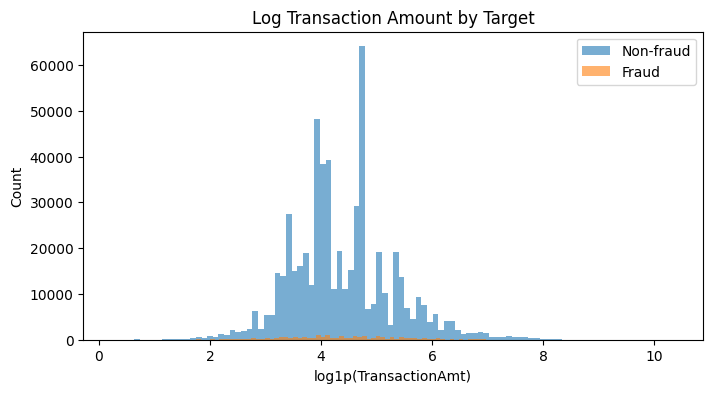

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(np.log1p(nonfraud_amt), bins=100, alpha=0.6, label="Non-fraud")
plt.hist(np.log1p(fraud_amt), bins=100, alpha=0.6, label="Fraud")
plt.title("Log Transaction Amount by Target")
plt.xlabel("log1p(TransactionAmt)")
plt.ylabel("Count")
plt.legend()
plt.show()

In [23]:
target = "isFraud"
id_col = "TransactionID"

num_cols = train.select_dtypes(include=["int64", "int32", "float64", "float32"]).columns.tolist()
cat_cols = train.select_dtypes(include=["object", "category"]).columns.tolist()

num_cols = [col for col in num_cols if col not in [target, id_col]]

print("Numeric columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numeric columns: 400
Categorical columns: 31


In [24]:
cat_summary = []

for col in cat_cols:
    cat_summary.append({
        "column": col,
        "unique_train": train[col].nunique(dropna=False),
        "missing_percent": train[col].isnull().mean() * 100
    })

cat_summary = pd.DataFrame(cat_summary)
cat_summary.sort_values("unique_train", ascending=False)


,column,unique_train,missing_percent
30,DeviceInfo,1787,79.905510
23,id_33,261,87.589494
22,id_31,131,76.245132
21,id_30,76,86.865411
4,R_emaildomain,61,76.751617
3,P_emaildomain,60,15.994852
0,ProductCD,5,0.000000
2,card6,5,0.266028
1,card4,5,0.267044
24,id_34,5,86.824771


In [25]:
def show_category_fraud_rate(df, col, top_n=20):
    temp = df.groupby(col)["isFraud"].agg(["count", "mean"])
    temp = temp.sort_values("count", ascending=False).head(top_n)

    display(temp)

    plt.figure(figsize=(10, 4))
    plt.bar(temp.index.astype(str), temp["mean"])
    plt.title(f"Fraud Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Fraud Rate")
    plt.xticks(rotation=45, ha="right")
    plt.show()

/tmp/ipykernel_57/209088169.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby(col)["isFraud"].agg(["count", "mean"])


,count,mean
ProductCD,,
W,439670,0.020399
C,68519,0.116873
R,37699,0.037826
H,33024,0.047662
S,11628,0.058996


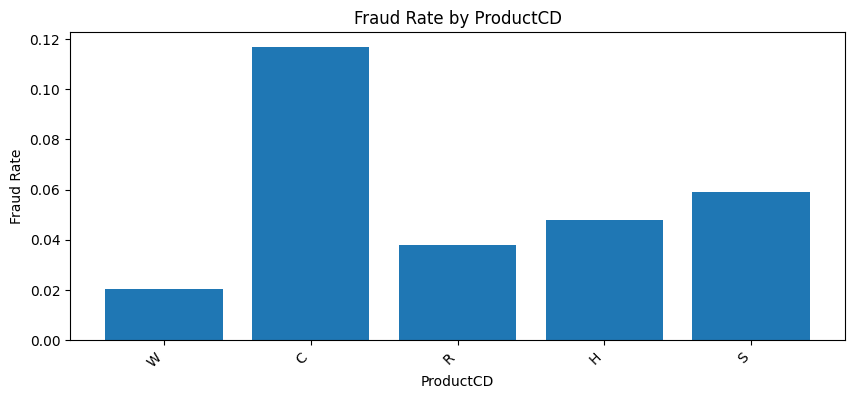

In [26]:
show_category_fraud_rate(train, "ProductCD")

/tmp/ipykernel_57/209088169.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby(col)["isFraud"].agg(["count", "mean"])


,count,mean
card4,,
visa,384767,0.034756
mastercard,189217,0.034331
american express,8328,0.028698
discover,6651,0.077282


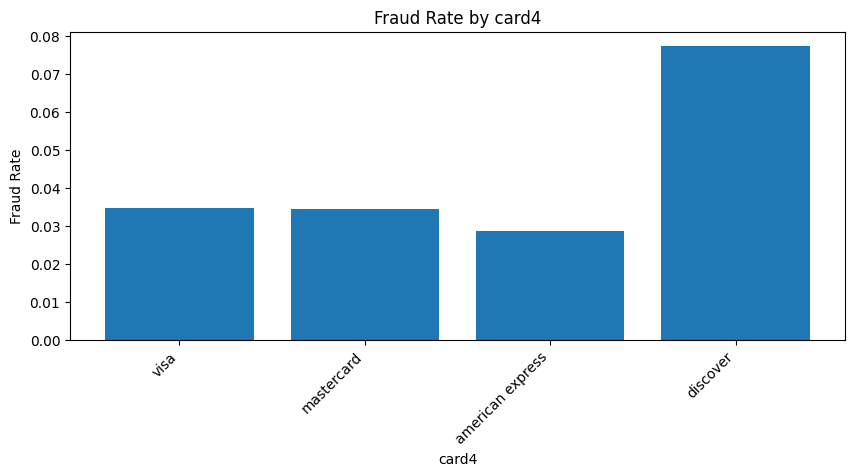

In [27]:
show_category_fraud_rate(train, "card4")

/tmp/ipykernel_57/209088169.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby(col)["isFraud"].agg(["count", "mean"])


,count,mean
card6,,
debit,439938,0.024263
credit,148986,0.066785
debit or credit,30,0.000000
charge card,15,0.000000


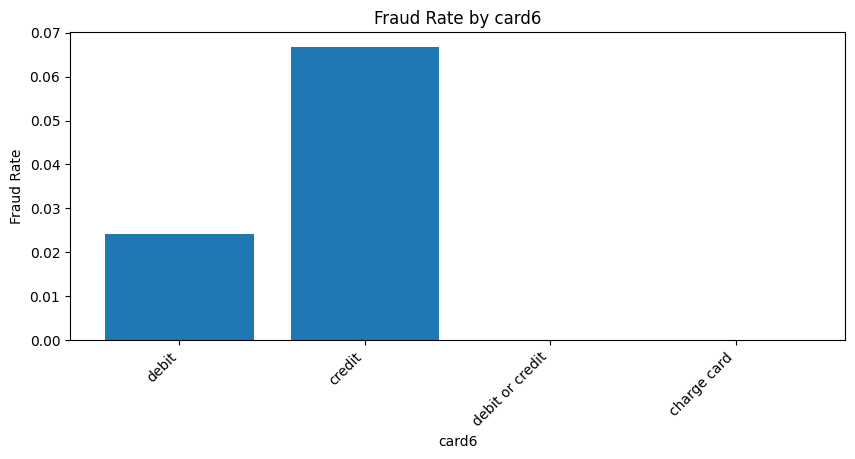

In [28]:
show_category_fraud_rate(train, "card6")

/tmp/ipykernel_57/209088169.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby(col)["isFraud"].agg(["count", "mean"])


,count,mean
P_emaildomain,,
gmail.com,228355,0.043542
yahoo.com,100934,0.022757
hotmail.com,45250,0.052950
anonymous.com,36998,0.023217
aol.com,28289,0.021811
comcast.net,7888,0.031187
icloud.com,6267,0.031434
outlook.com,5096,0.094584
msn.com,4092,0.021994


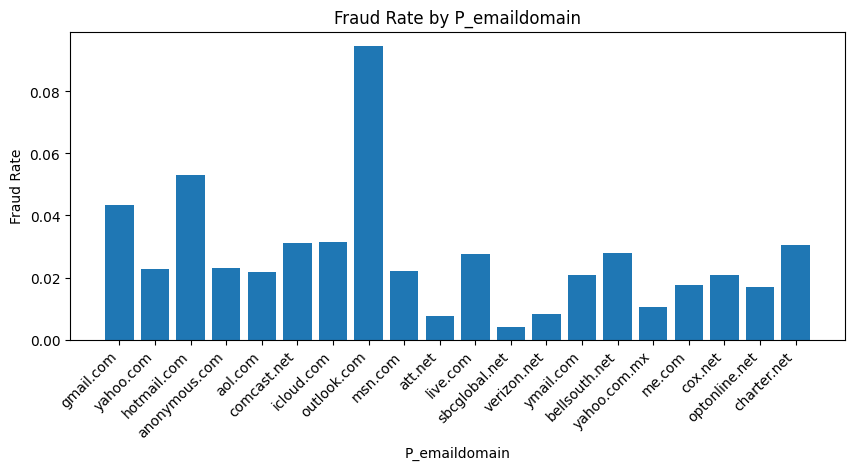

In [29]:
show_category_fraud_rate(train, "P_emaildomain")

/tmp/ipykernel_57/209088169.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  temp = df.groupby(col)["isFraud"].agg(["count", "mean"])


,count,mean
R_emaildomain,,
gmail.com,57147,0.119184
hotmail.com,27509,0.077793
anonymous.com,20529,0.029130
yahoo.com,11842,0.051512
aol.com,3701,0.034855
outlook.com,2507,0.165138
comcast.net,1812,0.011589
yahoo.com.mx,1508,0.010610
icloud.com,1398,0.128755


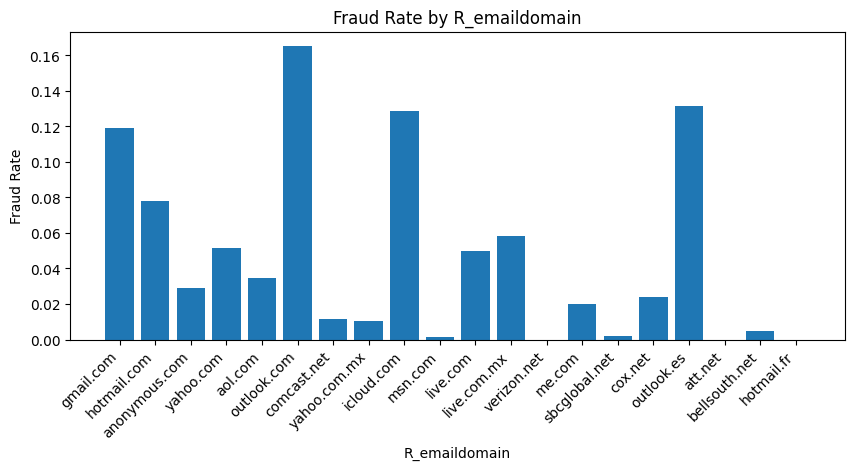

In [30]:
show_category_fraud_rate(train, "R_emaildomain")

In [33]:
corr_with_target = train[num_cols + [target]].corr(numeric_only=True)[target]
corr_with_target = corr_with_target.drop(target).sort_values(key=lambda x: x.abs(), ascending=False)

corr_with_target.head(30)

V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
V157    0.234866
V155    0.234199
V230    0.231740
V199    0.231024
V148    0.228891
V51     0.223191
V171    0.216508
V40     0.212442
V243    0.210238
V154    0.206958
Name: isFraud, dtype: float64

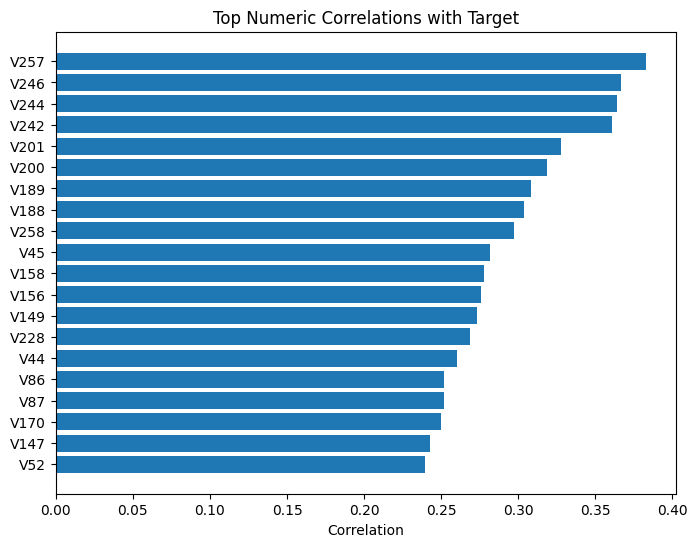

In [34]:
top_corr = corr_with_target.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top_corr.index[::-1], top_corr.values[::-1])
plt.title("Top Numeric Correlations with Target")
plt.xlabel("Correlation")
plt.show()

In [37]:
test_transaction = pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv")
test_identity = pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv")

test = test_transaction.merge(test_identity, on="TransactionID", how="left")
test = reduce_mem_usage(test)

Memory usage: 2164.10 MB -> 792.74 MB
Reduced by 63.37%


In [39]:
train["TransactionAmt_log"] = np.log1p(train["TransactionAmt"])
test["TransactionAmt_log"] = np.log1p(test["TransactionAmt"])

train["TransactionAmt_decimal"] = ((train["TransactionAmt"] % 1) * 1000).round()
test["TransactionAmt_decimal"] = ((test["TransactionAmt"] % 1) * 1000).round()

train["missing_count"] = train.isnull().sum(axis=1)

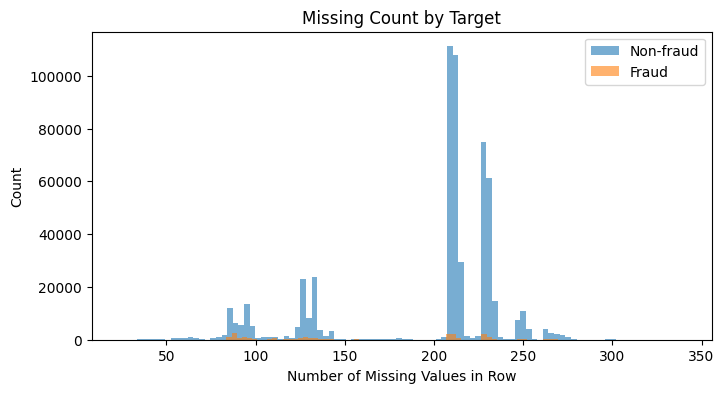

In [40]:
plt.figure(figsize=(8, 4))
plt.hist(train.loc[train["isFraud"] == 0, "missing_count"], bins=100, alpha=0.6, label="Non-fraud")
plt.hist(train.loc[train["isFraud"] == 1, "missing_count"], bins=100, alpha=0.6, label="Fraud")
plt.title("Missing Count by Target")
plt.xlabel("Number of Missing Values in Row")
plt.ylabel("Count")
plt.legend()
plt.show()

In [41]:
train.groupby("isFraud")["missing_count"].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,569877.0,196.852849,48.144999,24.0,208.0,211.0,229.0,340.0
1,20663.0,161.697817,60.000277,35.0,96.0,139.0,213.0,321.0
